In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os, yaml, sparse, itertools, subprocess, sys, pickle, re, collections, shutil, vcf, allel
from functools import reduce

import Bio.SeqUtils
import Bio.Data
from Bio import SeqIO
from Bio.Seq import Seq

plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.titlepad'] = 10
import scipy.stats as st
import warnings
warnings.filterwarnings("ignore")

from matplotlib.ticker import FormatStrFormatter
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
import statsmodels.stats.api as sm

results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"
data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"

os.chdir("../")
from epi_utils import *

# # who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")
# who_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_resistance_variants_all.csv")
# who_variants_clean = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/WHO_catalog_clean.csv")

h37Rv = SeqIO.read("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/GCF_000195955.2_ASM19595v2_genomic.gbff", "genbank")
h37Rv_genes = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/H37Rv/mycobrowser_h37rv_genes_v4.csv")

# coll2014 = pd.read_csv("/home/sak0914/who-analysis/data/coll2014_SNP_scheme.tsv", sep="\t")
# coll2014["#lineage"] = coll2014["#lineage"].str.replace("lineage", "")
# coll2014.rename(columns={"#lineage": "Lineage"}, inplace=True)

# solo_results = pd.read_excel("/home/sak0914/who-analysis/data/SOLO primary_STATA_ver18Feb2023.xlsx", sheet_name=None)

# if len(solo_results) == 1:
#     solo_results = solo_results[list(solo_results.keys())[0]]

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {val: key for key, val in drug_abbr_dict.items()}

# isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/WHO_catalog_isolate_variants.csv")

model_loci = pd.read_csv("../../data_processing/data_utils/drug_loci.csv")
who_variants = pd.read_csv("../../data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)
silent_lst = ['synonymous_variant', 'initiator_codon_variant', 'stop_retained_variant']
isolate_variants = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/TRUST/isolate_variants_WHO_catalog.csv")

cc_df = pd.read_csv("/home/sak0914/who-analysis/data/drug_CC.csv")

In [ ]:
for fName in :
    shutil.run(f"/n/scratch/users/s/sak0914/TRUST_TOTAL_VCF")

In [ ]:
bedtools subtract -a '-' -b /home/sak0914/Mtb_Megapipe/references/ref_genome/RLC_Regions.Plus.LowPmapK50E4.H37Rv.bed

In [49]:
# this is all WGS samples that we have matched with patients, not just WGS at baseline
df_full_WGS = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_summary.csv")

In [50]:
df_full_WGS.query("F2 > 0.1").shape

(22, 17)

In [51]:
# df = pd.read_csv("SNPs_only_all_WGS.csv", index_col=[0])
# df.shape

In [52]:
seqs = [(seq.id, seq.seq) for seq in SeqIO.parse("./SNP_distances/SNPs_only_all_WGS.fasta", "fasta")]

len(seqs), len(seqs[0][1])

(711, 16245)

In [150]:
keep_sites = pd.read_csv("./SNP_distances/keep_sites.csv").Site.values.astype(str)

genome_matrix = pd.read_csv("./SNP_distances/SNPs_only_all_WGS.csv", index_col=[0])
print(genome_matrix.shape)

genome_matrix = genome_matrix[keep_sites]
print(genome_matrix.shape)

(711, 33376)
(711, 16245)


In [153]:
df_trust_patients = pd.read_csv("./processed_data/combined_patients_WGS_samples.csv").query("F2 <= 0.1").sort_values(['pid', 'Original_ID']).drop_duplicates('pid', keep='first')

SNP_distance_matrix = pd.read_csv("./SNP_distances/SNP_distance_matrix.csv", index_col=[0])

keep_WGS = list(set(df_trust_patients.SampleID.values).intersection(SNP_distance_matrix.index.values))
print(len(keep_WGS))

df_trust_patients = df_trust_patients.query("SampleID in @keep_WGS")
SNP_distance_matrix = SNP_distance_matrix.loc[keep_WGS, keep_WGS]

# sort
# SNP_distance_matrix = SNP_distance_matrix.sort_index()[np.sort(SNP_distance_matrix.columns)]

# add household numbers
df_trust_patients = add_household_numbers(df_trust_patients)
print(df_trust_patients.dropna(subset='bl_housecode').groupby("bl_housecode")['pid'].nunique().unique())

# dummy variable for pivoting to matrix
df_trust_patients['col_vals'] = 1

411
71 patients share a household with another patient, accounting for 31 households
371 unique households across 411 patients
[4 2 3 1 6]


In [155]:
df_trust_patients.pid.nunique()

411

In [163]:
def do_two_samples_share_household(df_trust_patients, sample_1, sample_2):

    if df_trust_patients.query("SampleID in [@sample_1, @sample_2]").household_num.nunique() == 1:
        return 1

    return 0

In [164]:
df_trust_patients.columns[df_trust_patients.columns.str.contains('bl_house')]

Index(['bl_household', 'bl_housecode', 'bl_houseclose', 'bl_houseclosenum',
       'bl_houseclose_1code', 'bl_houseclose_1type', 'bl_houseclose_2code',
       'bl_houseclose_2type'],
      dtype='object')

In [166]:
# all_pairwise_combinations = list(itertools.combinations(keep_WGS, 2))
all_pairwise_combinations = list(itertools.product(SNP_distance_matrix.columns, SNP_distance_matrix.columns))
household_sharing_long = pd.DataFrame(all_pairwise_combinations)
household_sharing_long.columns = ['Sample1', 'Sample2']

# WGS samples of patients who do not share a household with any other participant
samples_no_household_share = df_trust_patients.query("bl_household==0").SampleID.unique()

household_sharing_long.loc[(household_sharing_long['Sample1'].isin(samples_no_household_share)) | (household_sharing_long['Sample2'].isin(samples_no_household_share)), 'Share_Household'] = 0

# NaN because they are the same. Can't share or not share
household_sharing_long.loc[household_sharing_long['Sample1'] == household_sharing_long['Sample2'], 'Share_Household'] = np.nan

# add additional annotations for the patient. So that you can see if two different samples came from the same patient
household_sharing_long = household_sharing_long.merge(df_trust_patients[['pid', 'SampleID']].rename(columns={'pid': 'pid1', 'SampleID': 'Sample1'}))
household_sharing_long = household_sharing_long.merge(df_trust_patients[['pid', 'SampleID']].rename(columns={'pid': 'pid2', 'SampleID': 'Sample2'}))

# NaN for these as well. No, I don't think so. Or, you just have to keep the earliest instance in all patient cases
# household_sharing_long.loc[(household_sharing_long['pid1'] == household_sharing_long['pid2']), 'Share_Household'] = np.nan

idx = 0

print(len(household_sharing_long.loc[(pd.isnull(household_sharing_long['Share_Household'])) & (household_sharing_long['pid1'] != household_sharing_long['pid2'])]))

for i, row in household_sharing_long.loc[(pd.isnull(household_sharing_long['Share_Household'])) & (household_sharing_long['pid1'] != household_sharing_long['pid2'])].iterrows():
    
    household_sharing_long.loc[i, 'Share_Household'] = do_two_samples_share_household(df_trust_patients, row['Sample1'], row['Sample2'])

    if idx % 1000 == 0:
        print(idx)

    idx += 1

4970
0
1000
2000
3000
4000


In [167]:
household_sharing_long.loc[(household_sharing_long['pid1'] == household_sharing_long['pid2'])].query("Sample1 != Sample2")

,Sample1,Sample2,Share_Household,pid1,pid2


In [168]:
household_sharing_long.Share_Household.unique(), len(household_sharing_long)

(array([nan,  0.,  1.]), 168921)

In [169]:
household_sharing_matrix = household_sharing_long.pivot(index='Sample1', columns='Sample2', values='Share_Household')

# check ordering
assert sum(household_sharing_matrix.index != SNP_distance_matrix.index) == 0
assert sum(household_sharing_matrix.columns != SNP_distance_matrix.columns) ==0 

AssertionError: 

In [104]:
def get_SNP_distances_by_household_share_variable(SNP_distance_matrix, share=True):

    vals_matrix = SNP_distance_matrix[household_sharing_matrix == int(share)]
    
    # create the upper triangular mask to remove symmetric duplicates, i.e. SAMPLE1/SAMPLE2 AND SAMPLE2/SAMPLE1 are the same value. 
    # np.triu and np.tril zero out the values, so need to add an additional step to make them NaN
    mask = np.triu(vals_matrix, k=0).astype(bool)

    # apply the upper triangular mask
    vals_matrix = vals_matrix.mask(mask, other=np.nan).values
    
    # drop the NaNs
    return vals_matrix[~np.isnan(vals_matrix)].astype(int)
    

SNP_distances_household_share = get_SNP_distances_by_household_share_variable(SNP_distance_matrix, share=True)
SNP_distances_no_household_share = get_SNP_distances_by_household_share_variable(SNP_distance_matrix, share=False)

len(SNP_distances_household_share), len(SNP_distances_no_household_share)

(57, 75409)

In [105]:
df_trust_patients.household_num.nunique()

354

In [106]:
df_plot = pd.concat([pd.DataFrame({'SNP_dist': SNP_distances_household_share, 'Share': 1}), 
                     pd.DataFrame({'SNP_dist': SNP_distances_no_household_share, 'Share': 0})
                    ])

print(len(df_plot))

# assert len(df_plot) == len(household_sharing_long) - household_sharing_matrix.index.nunique()
df_plot.to_csv("SNP_distances_long.csv", index=False)

75466


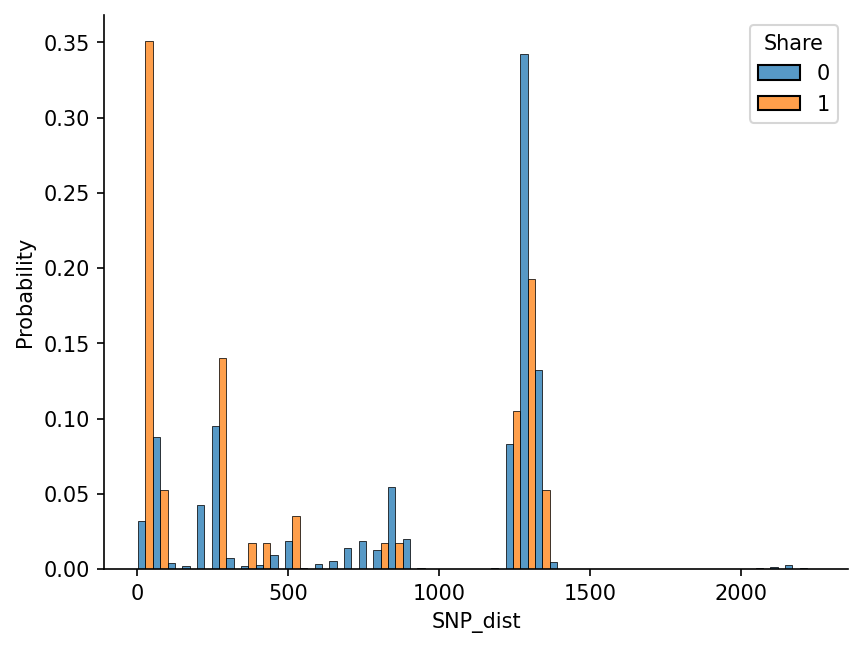

In [107]:
sns.histplot(data=df_plot,
             x='SNP_dist',
             hue='Share',
             common_norm=False,
             stat='probability',
             multiple='dodge'
            )

sns.despine()
plt.show()

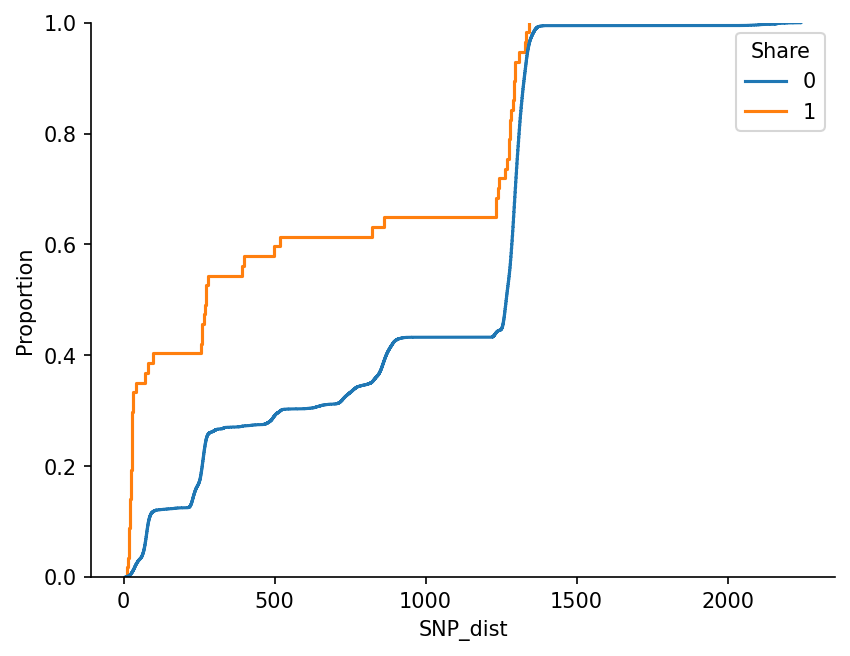

In [110]:
sns.ecdfplot(data=df_plot,
             x='SNP_dist',
             hue='Share',
            )

sns.despine()
plt.show()

In [70]:
df_plot.query("Share==0").SNP_dist.min(), df_plot.query("Share==1").SNP_dist.min()

(4, 11)

In [71]:
df_plot.query("Share==1").shape

(57, 2)

In [72]:
st.mannwhitneyu(df_plot.query("Share==1").SNP_dist,
                df_plot.query("Share==0").SNP_dist,
                alternative='less'
               )

MannwhitneyuResult(statistic=1246939.5, pvalue=2.0376252071510724e-08)

In [73]:
df_plot.query("Share==1").SNP_dist.median(), df_plot.query("Share==0").SNP_dist.median()

(272.0, 1267.0)

In [74]:
df_plot.query("Share==1").SNP_dist.mean(), df_plot.query("Share==0").SNP_dist.mean()

(561.6666666666666, 909.1573552228514)

In [75]:
df_trust_patients.query("SampleID in @keep_WGS & bl_household==1").pid.nunique()

65

In [171]:
df_fasta_file = pd.DataFrame([(seq.id, str(seq.seq)) for seq in SeqIO.parse("/home/sak0914/MtbQuantCNN/analysis/TRUST/SNP_concatenate.fasta", "fasta")])
df_fasta_file.columns = ['Isolate', 'Seq']

print(len(df_fasta_file))

df_fasta_file = df_fasta_file.query("Isolate in @df_save.ID").reset_index(drop=True)
print(len(df_fasta_file))

# constant_cols = df_fasta_file.loc[:, df_fasta_file.nunique() == 1].columns
# df_fasta_file = df_fasta_file.drop(columns=constant_cols)

711
711


In [167]:
with open("/home/sak0914/MtbQuantCNN/analysis/TRUST/SNP_concatenate.fasta", "w+") as file:

    for i, row in df_fasta_file.iterrows():

        file.write(f">{row['Isolate']}\n")
        file.write(f"{str(row['Seq'])}\n")

In [12]:
vcf_files = glob.glob(f"/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/*/pilon/*_variants.vcf")
len(vcf_files)

733

In [15]:
vcf_files[1]

'/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/MFS-10/pilon/MFS-10_variants.vcf'

In [ ]:
# get SNPs only
bcftools view --types snps,mnps MFS-1_variants.vcf | bgzip > MFS-1.SNPs.vcf.bgz

# rename SAMPLE column to the sample name so that the names will be distinct for merging
bcftools reheader MFS-1.SNPs.vcf.bgz -s new_name.txt -o MFS-1.SNPs.reheader.vcf.bgz

# index with tabix
tabix MFS-1.SNPs.reheader.vcf.bgz

In [ ]:
# get SNPs only
bcftools view --types snps,mnps MFS-10_variants.vcf | bgzip > MFS-10.SNPs.vcf.bgz

# rename SAMPLE column to the sample name so that the names will be distinct for merging
bcftools reheader MFS-10.SNPs.vcf.bgz -s new_name.txt -o MFS-10.SNPs.reheader.vcf.bgz

# index with tabix
tabix MFS-10.SNPs.reheader.vcf.bgz

In [ ]:
MFS-10.SNPs.reheader.vcf.bgz

In [18]:
pd.Series(['/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/MFS-1/pilon/MFS-1.SNPs.reheader.vcf.bgz', 
           '/n/data1/hms/dbmi/farhat/rollingDB/TRUST/Illumina_culture_WGS_processed/MFS-10/pilon/MFS-10.SNPs.reheader.vcf.bgz'
          ]).to_csv("./VCF_files.txt", sep='\t', header=None, index=False)

In [9]:
pd.Series(vcf_files[:10]).to_csv("./VCF_files.txt", sep='\t', header=None, index=False)

NameError: name 'vcf_files' is not defined

In [ ]:
# --missing-to-ref flag means that instead of ./., you will see 0/0. Assumes that if a variant is not present in a VCF, it's REF, which is true in this case.
bcftools merge -l ./VCF_files.txt --missing-to-ref -m snps